# 🚀 Day 5: Pandas Pivot Table & Data Visualization

## 30 Days of Machine Learning Challenge

Today I am learning how to summarize data using Pandas Pivot Tables
and visualize insights using Matplotlib and Seaborn.

### Objectives

- Understand Pandas pivot_table()
- Create summary tables
- Perform aggregation
- Create bar charts
- Create line charts
- Create scatter plots
- Create histograms
- Create heatmaps
- Interpret visualizations

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Create Dataset
data = {
    "Date": [
        "2026-01-05", "2026-01-10", "2026-01-15",
        "2026-02-05", "2026-02-12", "2026-02-20",
        "2026-03-03", "2026-03-10", "2026-03-18",
        "2026-04-02", "2026-04-12", "2026-04-20"
    ],
    "Product": [
        "Laptop", "Phone", "Laptop",
        "Tablet", "Phone", "Headphones",
        "Laptop", "Tablet", "Phone",
        "Headphones", "Laptop", "Phone"
    ],
    "Category": [
        "Electronics", "Electronics", "Electronics",
        "Electronics", "Electronics", "Accessories",
        "Electronics", "Electronics", "Electronics",
        "Accessories", "Electronics", "Electronics"
    ],
    "Region": [
        "North", "South", "West",
        "North", "South", "West",
        "North", "East", "West",
        "East", "South", "North"
    ],
    "Sales": [
        75000, 45000, 80000,
        30000, 50000, 12000,
        90000, 35000, 55000,
        15000, 85000, 60000
    ],
    "Quantity": [
        3, 5, 2,
        4, 6, 10,
        3, 5, 7,
        12, 2, 8
    ]
}

df = pd.DataFrame(data)

df

,Date,Product,Category,Region,Sales,Quantity
0,2026-01-05,Laptop,Electronics,North,75000,3
1,2026-01-10,Phone,Electronics,South,45000,5
2,2026-01-15,Laptop,Electronics,West,80000,2
3,2026-02-05,Tablet,Electronics,North,30000,4
4,2026-02-12,Phone,Electronics,South,50000,6
5,2026-02-20,Headphones,Accessories,West,12000,10
6,2026-03-03,Laptop,Electronics,North,90000,3
7,2026-03-10,Tablet,Electronics,East,35000,5
8,2026-03-18,Phone,Electronics,West,55000,7
9,2026-04-02,Headphones,Accessories,East,15000,12


In [4]:
#Explore the Dataset
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      12 non-null     object
 1   Product   12 non-null     object
 2   Category  12 non-null     object
 3   Region    12 non-null     object
 4   Sales     12 non-null     int64 
 5   Quantity  12 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 708.0+ bytes


,Sales,Quantity
count,12.000000,12.000000
mean,52666.666667,5.583333
std,26472.398433,3.175426
min,12000.000000,2.000000
25%,33750.000000,3.000000
50%,52500.000000,5.000000
75%,76250.000000,7.250000
max,90000.000000,12.000000


In [5]:
#Convert Date
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()

df

,Date,Product,Category,Region,Sales,Quantity,Month
0,2026-01-05,Laptop,Electronics,North,75000,3,January
1,2026-01-10,Phone,Electronics,South,45000,5,January
2,2026-01-15,Laptop,Electronics,West,80000,2,January
3,2026-02-05,Tablet,Electronics,North,30000,4,February
4,2026-02-12,Phone,Electronics,South,50000,6,February
5,2026-02-20,Headphones,Accessories,West,12000,10,February
6,2026-03-03,Laptop,Electronics,North,90000,3,March
7,2026-03-10,Tablet,Electronics,East,35000,5,March
8,2026-03-18,Phone,Electronics,West,55000,7,March
9,2026-04-02,Headphones,Accessories,East,15000,12,April


## 📌 What is a Pivot Table?

A Pivot Table summarizes large amounts of data by grouping values
and applying aggregation functions such as:

- sum
- mean
- count
- min
- max

It helps us quickly answer business questions.

In [6]:
# What is total sales by product?
product_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Product",
    aggfunc="sum"
)

product_sales

,Sales
Product,
Headphones,27000
Laptop,330000
Phone,210000
Tablet,65000


In [7]:
#Sales by Region
region_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    aggfunc="sum"
)

region_sales

,Sales
Region,
East,50000
North,255000
South,180000
West,147000


In [8]:
# Average Sales by Product
avg_product_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Product",
    aggfunc="mean"
)

avg_product_sales

,Sales
Product,
Headphones,13500.0
Laptop,82500.0
Phone,52500.0
Tablet,32500.0


In [9]:
# Product × Region Pivot Table
product_region = pd.pivot_table(
    df,
    values="Sales",
    index="Product",
    columns="Region",
    aggfunc="sum",
    fill_value=0
)

product_region

Region,East,North,South,West
Product,,,,
Headphones,15000,0,0,12000
Laptop,0,165000,85000,80000
Phone,0,60000,95000,55000
Tablet,35000,30000,0,0


In [10]:
#Multiple Aggregations
summary = pd.pivot_table(
    df,
    values=["Sales", "Quantity"],
    index="Category",
    aggfunc={
        "Sales": ["sum", "mean"],
        "Quantity": "sum"
    }
)

summary

Quantity    Sales        
                 sum     mean     sum
Category                             
Accessories       22  13500.0   27000
Electronics       45  60500.0  605000

## 📊 Data Visualization

Data visualization represents data using graphical formats.

It helps us:

- Identify patterns
- Find trends
- Compare categories
- Detect relationships
- Communicate insights

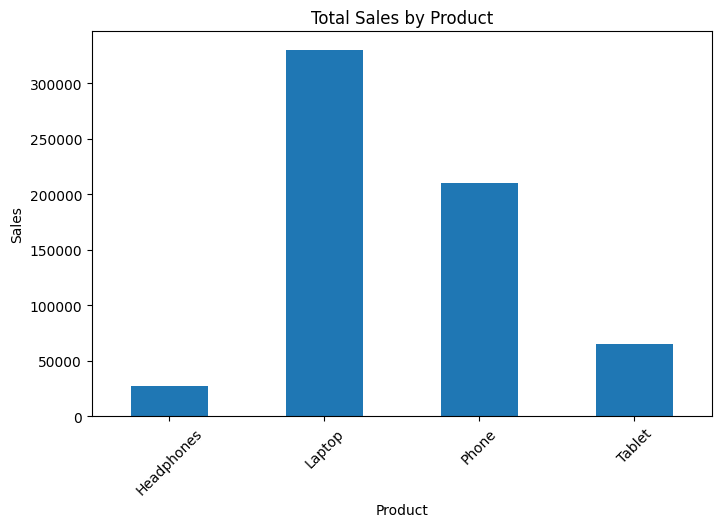

In [11]:
# Which product generated the highest sales?#
product_sales = df.groupby("Product")["Sales"].sum()

plt.figure(figsize=(8, 5))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

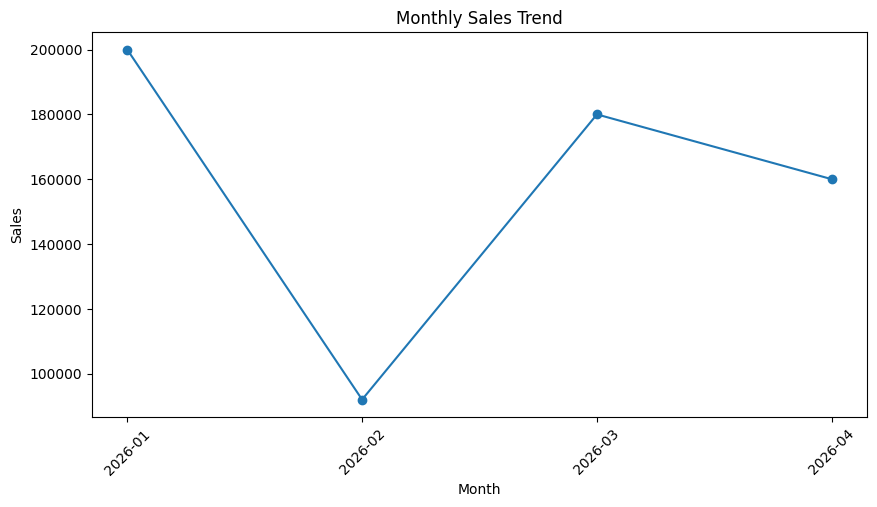

In [12]:
#How do sales change over time?

monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Sales"].sum()


monthly_sales.index = monthly_sales.index.astype(str)


plt.figure(figsize=(10, 5))


plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)


plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")


plt.xticks(rotation=45)


plt.show()


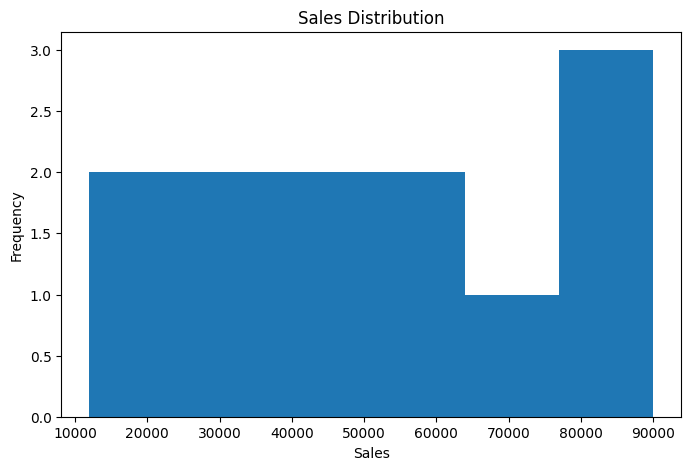

In [13]:
# How are sales values distributed?

plt.figure(figsize=(8, 5))


plt.hist(
    df["Sales"],
    bins=6
)


plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")


plt.show()

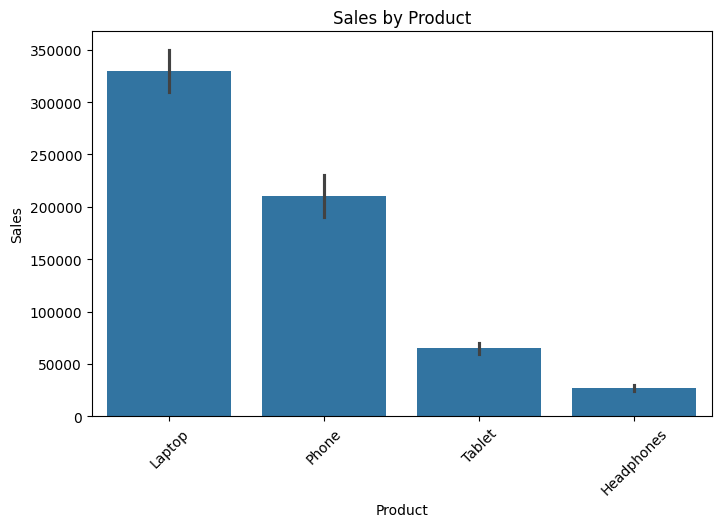

In [14]:
# Seaborn Bar Plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Product",
    y="Sales",
    estimator="sum"
)

plt.title("Sales by Product")
plt.xticks(rotation=45)

plt.show()

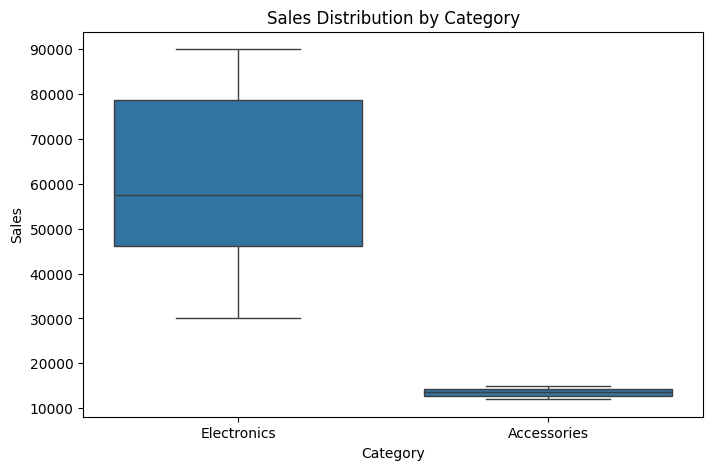

In [15]:
# A box plot helps identify the distribution and potential outliers.

plt.figure(figsize=(8, 5))


sns.boxplot(
    data=df,
    x="Category",
    y="Sales"
)


plt.title("Sales Distribution by Category")


plt.show()

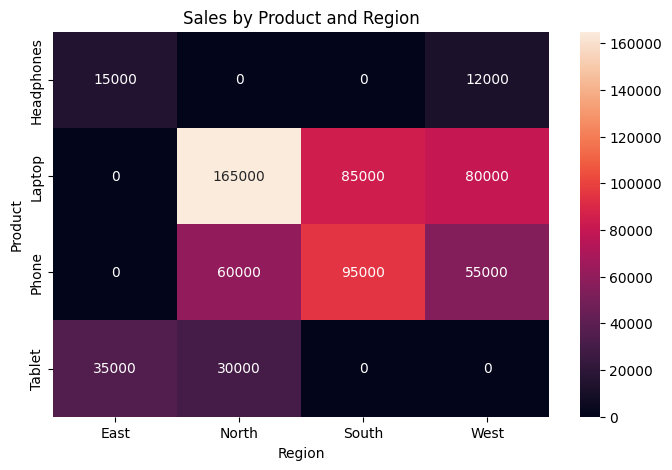

In [16]:
# heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(
    product_region,
    annot=True,
    fmt=".0f"
)

plt.title("Sales by Product and Region")

plt.show()

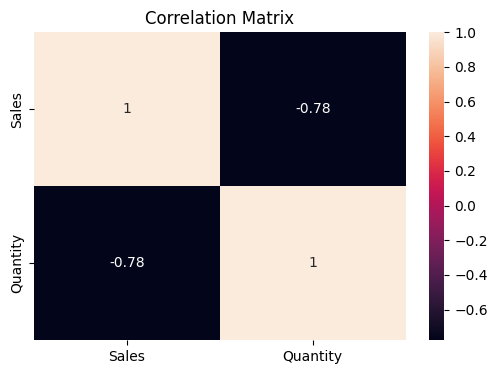

In [17]:
correlation = df[["Sales", "Quantity"]].corr()
correlation

plt.figure(figsize=(6, 4))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

## 💼 Business Questions

Using our dataset, we can answer:

1. Which product has the highest sales?
2. Which region generates the most revenue?
3. Which product sells the highest quantity?
4. What is the monthly sales trend?
5. Is quantity related to sales?
6. Which category performs better?
7. Are there potential outliers in sales?

In [18]:
print("Total Sales:", df["Sales"].sum())

print(
    "\nBest Selling Product:"
)

print(
    df.groupby("Product")["Sales"]
    .sum()
    .idxmax()
)

print(
    "\nBest Performing Region:"
)

print(
    df.groupby("Region")["Sales"]
    .sum()
    .idxmax()
)

print(
    "\nTotal Quantity Sold:",
    df["Quantity"].sum()
)

Total Sales: 632000

Best Selling Product:
Laptop

Best Performing Region:
North

Total Quantity Sold: 67
